# GP Heteroscedastic Regression Tutorial

Purpose: model load-dependent noise where aleatoric uncertainty grows with input magnitude.


## Learning Roadmap

- Distinguish epistemic and aleatoric uncertainty in noisy regimes.
- Verify whether learned aleatoric pattern follows true noise trend.
- Use decomposition plots to avoid over-interpreting total variance.


In [1]:
# Step 1: import heteroscedastic GP model and utilities
# Configure Python path for local package imports
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'gp' else Path.cwd().resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)

from deepuq.models import HeteroscedasticGaussianProcessRegressor, RBFKernel


In [2]:
# Step 2: define calibration metrics
def regression_metrics(y_true, mean, var):
    y_true = y_true.reshape(-1)
    mean = mean.reshape(-1)
    var = var.reshape(-1).clamp_min(1e-8)
    rmse = torch.sqrt(torch.mean((mean - y_true) ** 2)).item()
    nll = 0.5 * torch.mean(torch.log(2 * torch.pi * var) + (y_true - mean) ** 2 / var).item()
    std = torch.sqrt(var)
    lower = mean - 1.96 * std
    upper = mean + 1.96 * std
    coverage95 = torch.mean(((y_true >= lower) & (y_true <= upper)).float()).item()
    width95 = torch.mean(upper - lower).item()
    return {
        'rmse': rmse,
        'nll': nll,
        'coverage95': coverage95,
        'interval_width95': width95,
    }


In [3]:
# Step 3: synthesize data with input-dependent noise
x_train = torch.linspace(-4, 4, 140).unsqueeze(-1)
true_fn = lambda x: 0.4 * torch.sin(1.5 * x) + 0.05 * x**2
noise_std = 0.05 + 0.04 * torch.abs(x_train)
y_train = true_fn(x_train) + noise_std * torch.randn_like(x_train)

x_test = torch.linspace(-5.5, 5.5, 320).unsqueeze(-1)
y_test = true_fn(x_test)


In [4]:
# Step 4: fit heteroscedastic GP and evaluate metrics
het_gp = HeteroscedasticGaussianProcessRegressor(
    mean_kernel=RBFKernel(lengthscale=0.9, outputscale=1.0),
    noise_kernel=RBFKernel(lengthscale=1.1, outputscale=0.7),
    num_alternations=6,
)
het_gp.fit(x_train, y_train)
uq = het_gp.predict_uq(x_test)
metrics = regression_metrics(y_test.squeeze(-1), uq.mean, uq.total_var)
print({k: round(v, 4) for k, v in metrics.items()})


{'rmse': 0.4357, 'nll': -0.1393, 'coverage95': 0.9, 'interval_width95': 65.7607}


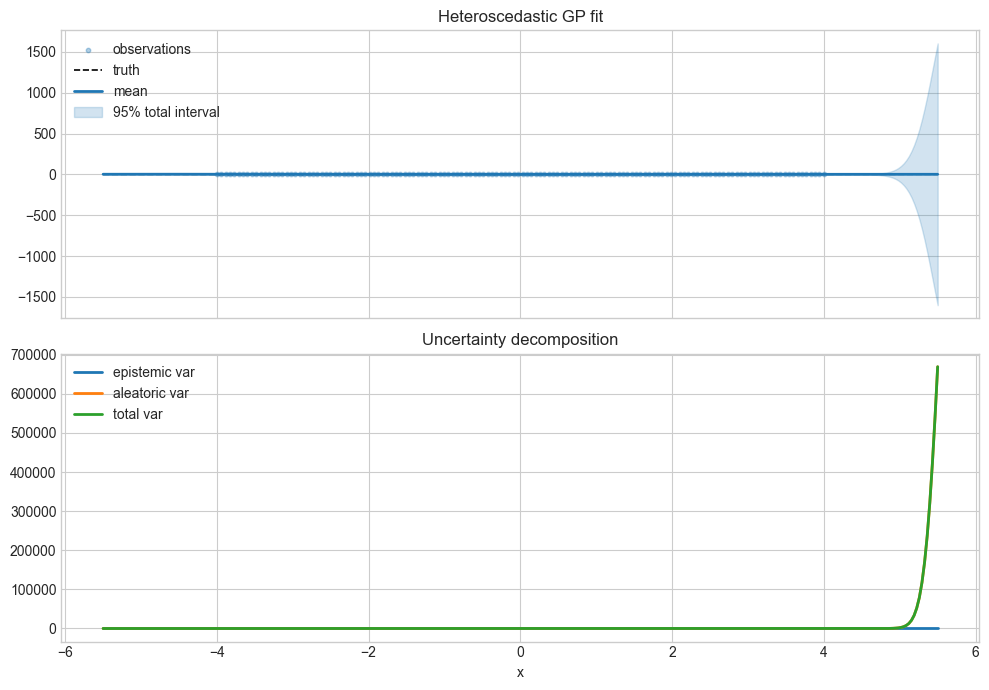

In [5]:
# Step 5: visualize fit plus uncertainty decomposition
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
std_total = torch.sqrt(uq.total_var)
axes[0].scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.35, label='observations')
axes[0].plot(x_test.numpy(), y_test.numpy(), 'k--', lw=1.2, label='truth')
axes[0].plot(x_test.numpy(), uq.mean.numpy(), color='tab:blue', lw=2, label='mean')
axes[0].fill_between(
    x_test.squeeze(-1).numpy(),
    (uq.mean - 1.96 * std_total).numpy(),
    (uq.mean + 1.96 * std_total).numpy(),
    alpha=0.2,
    color='tab:blue',
    label='95% total interval',
)
axes[0].legend(loc='best')
axes[0].set_title('Heteroscedastic GP fit')

axes[1].plot(x_test.numpy(), uq.epistemic_var.numpy(), label='epistemic var', lw=2)
axes[1].plot(x_test.numpy(), uq.aleatoric_var.numpy(), label='aleatoric var', lw=2)
axes[1].plot(x_test.numpy(), uq.total_var.numpy(), label='total var', lw=2)
axes[1].legend(loc='best')
axes[1].set_title('Uncertainty decomposition')
axes[1].set_xlabel('x')
plt.tight_layout()
plt.show()


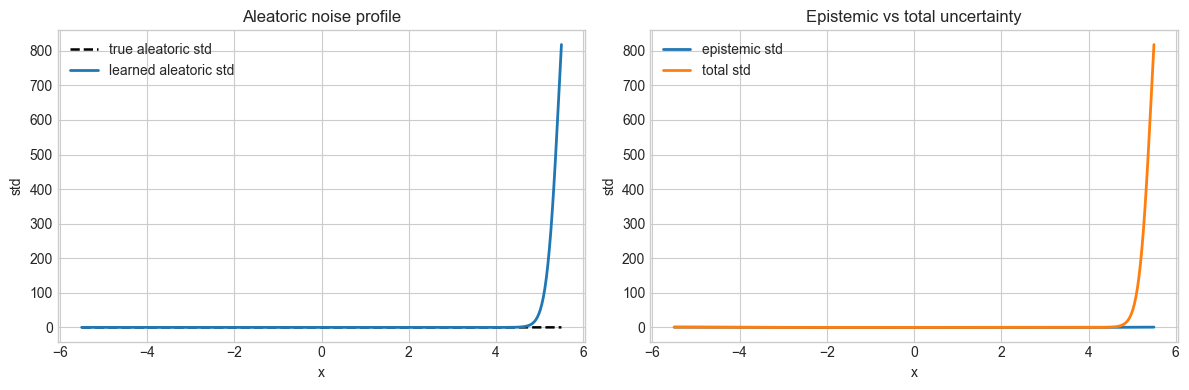

In [6]:
# Additional diagnostic: compare true and learned aleatoric noise profiles
# In this synthetic example, we know the true noise profile and can compare directly.
true_noise_std = (0.05 + 0.04 * torch.abs(x_test)).squeeze(-1)
learned_noise_std = torch.sqrt(uq.aleatoric_var)

epi_std = torch.sqrt(uq.epistemic_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_test.numpy(), true_noise_std.numpy(), 'k--', lw=1.8, label='true aleatoric std')
axes[0].plot(x_test.numpy(), learned_noise_std.numpy(), lw=2, label='learned aleatoric std')
axes[0].set_title('Aleatoric noise profile')
axes[0].set_xlabel('x')
axes[0].set_ylabel('std')
axes[0].legend(loc='best')

axes[1].plot(x_test.numpy(), epi_std.numpy(), lw=2, label='epistemic std')
axes[1].plot(x_test.numpy(), torch.sqrt(uq.total_var).numpy(), lw=2, label='total std')
axes[1].set_title('Epistemic vs total uncertainty')
axes[1].set_xlabel('x')
axes[1].set_ylabel('std')
axes[1].legend(loc='best')
plt.tight_layout()
plt.show()
